In [1]:
using Pkg
using Metal

cd(@__DIR__)
Pkg.activate("../")
ParamFile = "../config/testparam.csv"  # maybe GeoPoints and planet1D should be fusioned

# batchGPU should be at this level (I have not made it as a module yet, since the choice of Metal/CUDA should be done in a manual way)
include("../src/batchFiles/batchGPU.jl")


include("../src/commonBatchs.jl")
include("../src/flexOPT.jl")
include("../src/planet1D.jl")
include("../src/GeoPoints.jl")

using .commonBatchs, .flexOPT, .planet1D, .GeoPoints

  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend


In [2]:
famousEquationType="2DacousticTime"

config= (
    name = "OPT3",
    orderBtime = 1,
    orderBspace = 1,
    pointsInSpace = 3,
    pointsInTime = 3,
    supplementaryOrder = 2,
    fieldItpl = (
        ptsSpace = 1, ptsTime = 1,
        offsetSpace = 1.0, offsetTime = 1,
        YorderBspace = -2, YorderBtime = 1,
    ),
    materItpl = (
        ptsSpace = 3, ptsTime = 1,
        offsetSpace = 0, offsetTime = 1,
        YorderBspace = -1, YorderBtime = 1,
    ),
)

(name = "OPT3", orderBtime = 1, orderBspace = 1, pointsInSpace = 3, pointsInTime = 3, supplementaryOrder = 2, fieldItpl = (ptsSpace = 1, ptsTime = 1, offsetSpace = 1.0, offsetTime = 1, YorderBspace = -2, YorderBtime = 1), materItpl = (ptsSpace = 3, ptsTime = 1, offsetSpace = 0, offsetTime = 1, YorderBspace = -1, YorderBtime = 1))

Loading from ./tmp/AuthorsCoordInfo.jld2
Loading from ./tmp/seismicModelAuthors.jld2


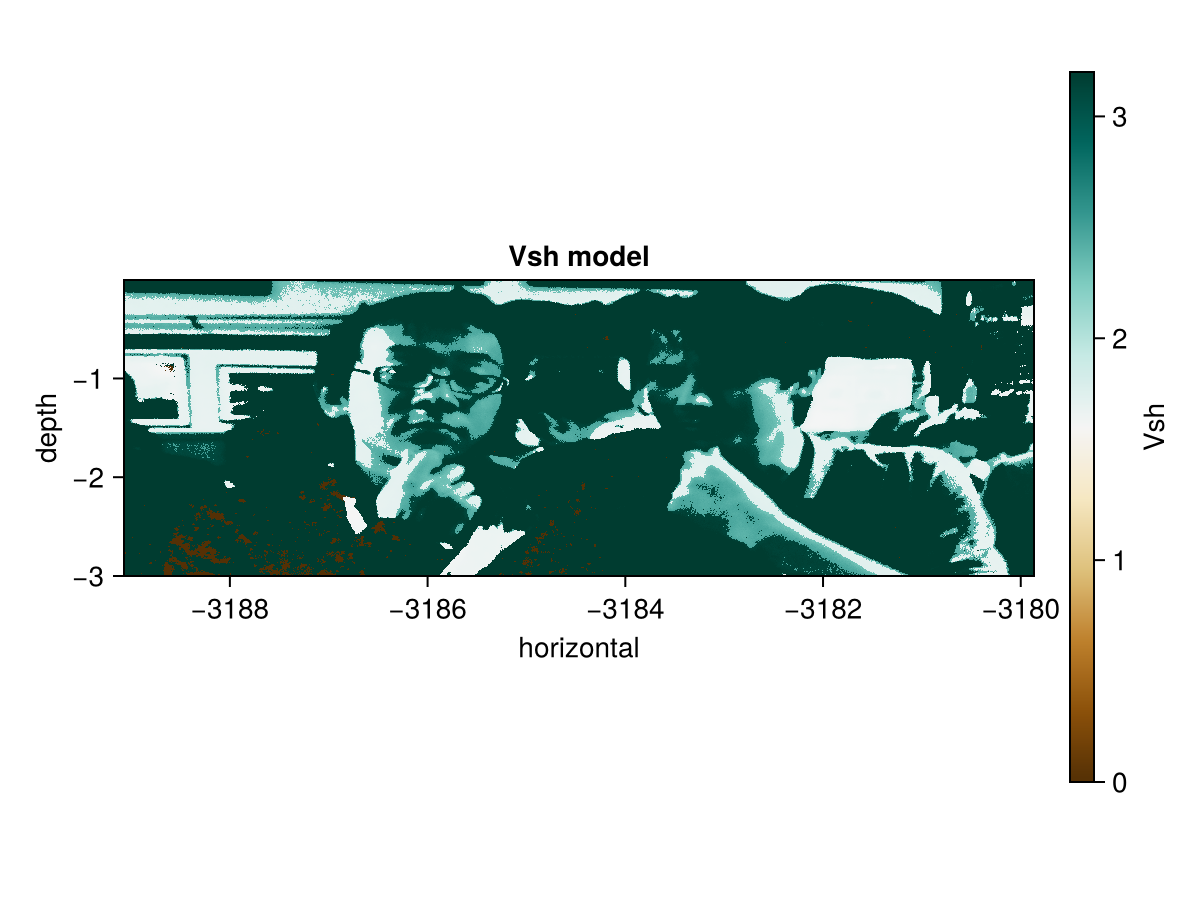

In [3]:
modelName="authors"
imageFile="../dataInput/model/moi/authors.png"
modelDefinitionMethod="2DimageFile" # ToyModel or 2DimageFile (or 1DsphericalPlanet)
model=defineModel(imageFile);
#
#boxGridsMarmousi = constructLocalBox(model,-3000.0,0.0,0.0,9200.0)
boxGrids = lazyProduceOrLoad("AuthorsCoordInfo",constructLocalBox,model,-3000.0,0.0,0.0,9200.0)
#seismicModelMarmousi = makeAdHocSeismicModel(model, 1.0, 2.8, 1.5, 5.5, 0.0, 3.2)
seismicModel=lazyProduceOrLoad("seismicModelAuthors",makeAdHocSeismicModel,model, 1.0, 2.8, 1.5, 5.5, 0.0, 3.2)

#constructLocalBox for marmousi models should be written!
using CairoMakie
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:,1]]*1.e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1,:]]*1.e-3
fig, ax, hm = heatmap(
    #topo.x,topo.y,topo.z';
    #collect((0:1:(Nx-1)).*Δx).*1.e-3,(collect(0:1:(Nz-1)).*Δz.+altMin).*1.e-3, seismicModel.ρ;
    xvals, zvals, seismicModel.Vsh;
    colormap = :BrBG,
    #colorrange=(0,4),
    axis = (aspect = DataAspect(), xlabel = "horizontal", ylabel = "depth", title = "Vsh model")
)
Colorbar(fig[1,2], hm, label="Vsh")
fig

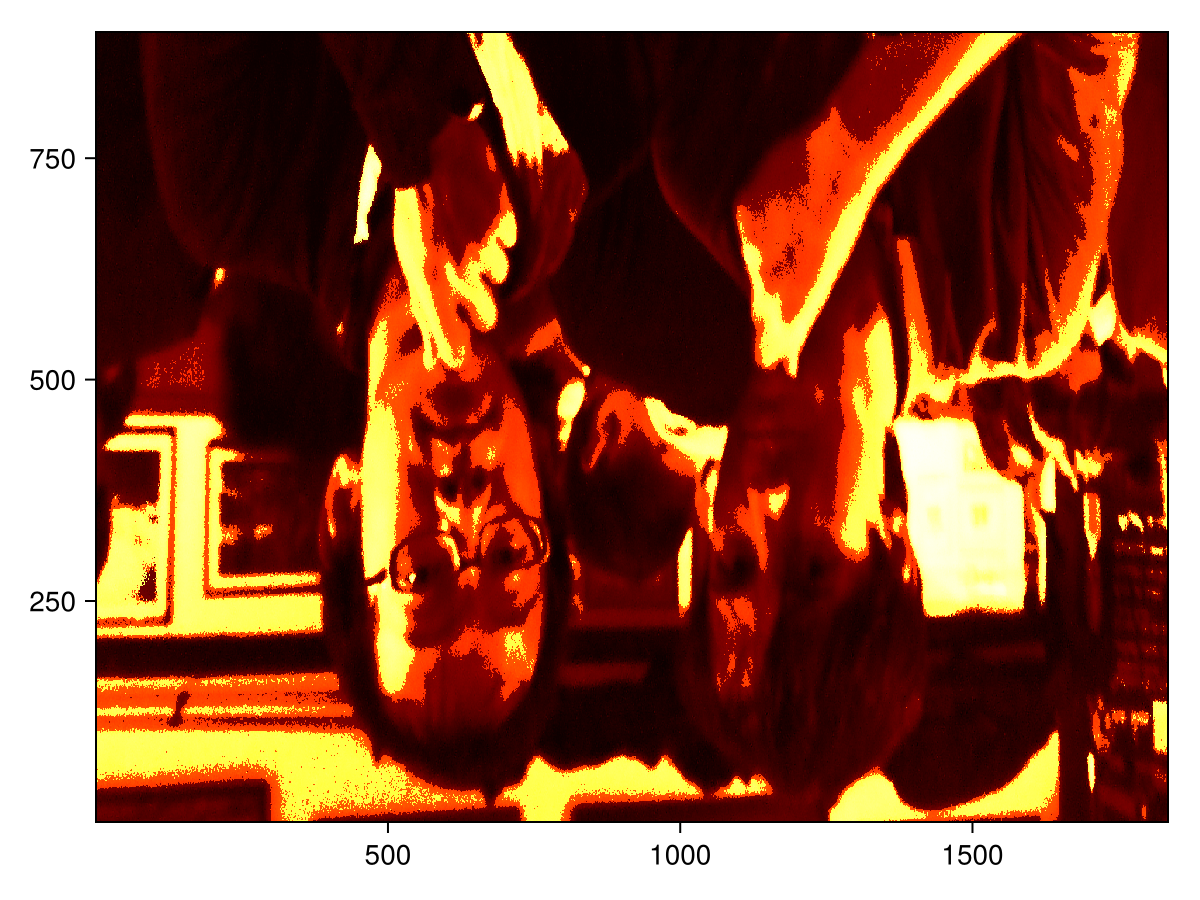

size(floatMatrix) = (1834, 892)
(maximum(data), minimum(data)) = (3295.4215188613516, 1000.0)
(maximum(data), minimum(data)) = (4943.132278292027, 1500.0)
(maximum(data), minimum(data)) = (2907.7248695835456, 882.3529411764706)


6543712

In [8]:
imagefile = "../dataInput/model/moi/authors.png"
colormap = "hot" #colormap can be RGB vector or predefined colormap

floatMatrix=read2DimageModel(imagefile,colormap;min=1000,max=3300, showRecoveredImage=true) 
@show size(floatMatrix)

# Brocher (2005)
function vp_from_rho(rho::Float64)
    return rho*1.5
end

function vs_from_vp(vp::Float64)
    return vp/1.7
end

# this is only for Lyon concours use!

data=floatMatrix
@show maximum(data),minimum(data)
  # Convert to Float32 (single precision)
data_single = Float32.(data)

# Flatten in column-major order (Fortran-style)
data_vec = vec(data_single)

# Write to binary file
open("GCNF.rho", "w") do io
    write(io, data_vec)
end



data=vp_from_rho.(data)
@show maximum(data),minimum(data)
# Convert to Float32 (single precision)
data_single = Float32.(data)

# Flatten in column-major order (Fortran-style)
data_vec = vec(data_single)

# Write to binary file
open("GCNF.vp", "w") do io
    write(io, data_vec)
end


data=vs_from_vp.(data)
@show maximum(data),minimum(data)
# Convert to Float32 (single precision)
data_single = Float32.(data)

# Flatten in column-major order (Fortran-style)
data_vec = vec(data_single)

# Write to binary file
open("GCNF.vs", "w") do io
    write(io, data_vec)
end

In [4]:
Δnum = (boxGrids.Δx,boxGrids.Δz,1.0) 
modelAuth=(models=((seismicModel.Vsh)),modelName="authors",modelPoints=(size(seismicModel.Vsh)...,10))


(models = [3.2 3.2 … 3.2 3.2; 3.2 3.2 … 3.2 3.2; … ; 3.2 3.2 … 3.2 3.2; 3.2 3.2 … 3.2 3.2], modelName = "authors", modelPoints = (1834, 892, 10))

In [5]:
@unpack orderBtime, orderBspace, pointsInSpace, pointsInTime, supplementaryOrder, fieldItpl, materItpl = config


concreteParametersForOPTConstruction = @strdict famousEquationType Δ=Δnum orderBtime orderBspace pointsInSpace pointsInTime supplementaryOrder fieldItpl materItpl
#optRec = myProduceOrLoad(makeOPTsemiSymbolic, concreteParametersForOPTConstruction, "semiSymbolic")
makeOPTsemiSymbolic(concreteParametersForOPTConstruction)

pointsIndices = availablePointsConfigurations[iConfigGeometry] = SVector{3, Int64}[[1, 1, 1] [1, 2, 1] [1, 3, 1]; [2, 1, 1] [2, 2, 1] [2, 3, 1]; [3, 1, 1] [3, 2, 1] [3, 3, 1];;; [1, 1, 2] [1, 2, 2] [1, 3, 2]; [2, 1, 2] [2, 2, 2] [2, 3, 2]; [3, 1, 2] [3, 2, 2] [3, 3, 2];;; [1, 1, 3] [1, 2, 3] [1, 3, 3]; [2, 1, 3] [2, 2, 3] [2, 3, 3]; [3, 1, 3] [3, 2, 3] [3, 3, 3]]
middleLinearν = centrePointConfigurations[iConfigGeometry] = 14
μPoints = availableμPoints[iConfigGeometry] = SVector{3, Float64}[[2.0, 2.0, 2.0];;;]
μᶜPoints = availableμᶜPoints[iConfigGeometry] = SVector{3, Float64}[[1.0, 1.0, 2.0] [1.0, 2.0, 2.0] [1.0, 3.0, 2.0]; [2.0, 1.0, 2.0] [2.0, 2.0, 2.0] [2.0, 3.0, 2.0]; [3.0, 1.0, 2.0] [3.0, 2.0, 2.0] [3.0, 3.0, 2.0];;;]
μaxes = availableμaxes[iConfigGeometry] = ([2.0], [2.0], [2.0])
μᶜaxes = availableμᶜaxes[iConfigGeometry] = ([1.0, 2.0, 3.0], [1.0, 2.0, 3.0], [2.0])
size(μPoints) = (1, 1, 1)
pointν = pointsIndices[middleLinearν] = [2, 2, 2]


┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/WYYKKIntegralSymbolic/WYYKKIntegralSymbolic_93e22b9d.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106


ErrorException: idx_selectedPoints should be a subset of idx_refPoints_original

In [6]:
continue
params = @strdict optRec=optRec modelFam=modelAuth absorbingBoundaries=nothing maskedRegionInSpace=nothing
numOpt = numericalOperatorConstruction(params)

numOps = numOpt["numOperators"]

ErrorException: syntax: break or continue outside loop